In [12]:
import os

In [18]:
new_images_path = './coco_converted/train/images/'
new_labels_path = './coco_converted/train/labels/'

os.makedirs(new_images_path, exist_ok=True)
os.makedirs(new_labels_path, exist_ok=True)

new_images_path = './coco_converted/val/images/'
new_labels_path = './coco_converted/val/labels/'

os.makedirs(new_images_path, exist_ok=True)
os.makedirs(new_labels_path, exist_ok=True)

new_images_path = './coco_converted/test/images/'
new_labels_path = './coco_converted/test/labels/'

os.makedirs(new_images_path, exist_ok=True)
os.makedirs(new_labels_path, exist_ok=True)

import shutil
images_path = '/home/samuel/SDU/MasterThesis/AI/test-1/train/images'
labels_path = '/home/samuel/SDU/MasterThesis/AI/test-1/train/labels'

images = sorted(os.listdir(images_path))
labels = sorted(os.listdir(labels_path))

train_percantage = 0.8
val_percentage = 0.1
test_percentage = 0.1

images_length = len(images)
train_end = int(images_length * train_percantage)
val_end = int(images_length * val_percentage)
test_end = int(images_length * test_percentage)

for i, image in enumerate(images):
    label = image.replace('.jpg', '.txt')
    if( not os.path.exists(os.path.join(labels_path, label))):
        continue
    if i < train_end:
        shutil.copy(os.path.join(images_path, image), './coco_converted/train/images/')
        shutil.copy(os.path.join(labels_path, label), './coco_converted/train/labels/')
    elif i < train_end + val_end:
        shutil.copy(os.path.join(images_path, image), './coco_converted/val/images/')
        shutil.copy(os.path.join(labels_path, label), './coco_converted/val/labels/')
    else:
        shutil.copy(os.path.join(images_path, image), './coco_converted/test/images/')
        shutil.copy(os.path.join(labels_path, label), './coco_converted/test/labels/')

In [19]:
#create dataset.yaml file
with open('./coco_converted/dataset.yaml', 'w') as f:
    f.write('train: ./train/images/\n')
    f.write('val: ./train/images/\n')
    f.write('\n')
    f.write('nc: 1\n')
    f.write("names: ['Potatoes']\n")

['0', '0.5807221030042918', '0.6055547210300428', '0.5841652360515022', '0.6041523605150215', '0.5850568669527897', '0.5993079399141631', '0.5868422746781116', '0.6003272532188841', '0.5895193133047211', '0.5991802575107297', '0.5934721030042919', '0.5929334763948498', '0.5934721030042919', '0.5972682403433477', '0.5975515021459228', '0.5968851931330472', '0.6018862660944205', '0.5921684549356223', '0.5995922746781116', '0.5879603004291846', '0.5976791845493563', '0.5860482832618026', '0.5964045064377683', '0.5785257510729614', '0.5924517167381974', '0.5778884120171673', '0.5929624463519313', '0.5703658798283262', '0.5823798283261803', '0.5707489270386266', '0.5772800429184549', '0.5678165236051502', '0.5748572961373392', '0.5690912017167382', '0.5734549356223176', '0.574574034334764', '0.5684828326180258', '0.5747006437768241', '0.5695032188841203', '0.5865579399141632', '0.5633830472103004', '0.5898733905579399', '0.5605783261802575', '0.5990525751072961', '0.5682274678111587', '0.59

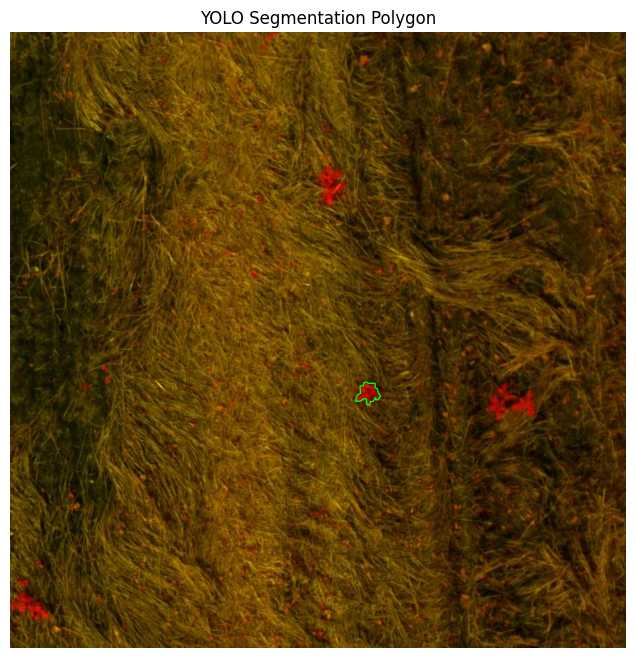

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Paths
# ------------------------------
image_path = "/home/samuel/SDU/MasterThesis/AI/test-1/train/images/tile_1_1_NEN_png.rf.5ec4022c12009321eb5198e85bb11010.jpg"
label_path = "/home/samuel/SDU/MasterThesis/AI/test-1/train/labels/tile_1_1_NEN_png.rf.5ec4022c12009321eb5198e85bb11010.txt"

# ------------------------------
# Load image
# ------------------------------
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# ------------------------------
# Load YOLO segmentation label
# ------------------------------
with open(label_path, "r") as f:
    line = f.readline().strip().split() 
    print(line)

    cls = int(line[0])
    coords = list(map(float, line[1:]))

    # ------------------------------
    # Convert normalized polygon coords -> pixel coords
    # ------------------------------
    points = []
    for i in range(0, len(coords), 2):
        x = int(coords[i] * w)
        y = int(coords[i+1] * h)
        points.append([x, y])

    points = np.array(points)

    # ------------------------------
    # Plot with matplotlib
    # ------------------------------
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.fill(points[:,0], points[:,1], facecolor='none', edgecolor='lime', linewidth=1)

    # Optionally close polygon explicitly
    plt.plot([points[-1,0], points[0,0]], [points[-1,1], points[0,1]], color='lime')

plt.title("YOLO Segmentation Polygon")
plt.axis("off")
plt.show()


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
1
NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:

from roboflow import Roboflow
rf = Roboflow(api_key="yJRFHPReLeXdSR5h3CKW")
project = rf.workspace("samwise101").project("test-cmaps")
version = project.version(1)
dataset = version.download("yolov11")
                
print("Dataset downloaded from Roboflow")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to test-1 in yolov11:: 100%|██████████| 696/696 [00:00<00:00, 6371.89it/s]

Dataset downloaded from Roboflow


In [ ]:
#start yolo segmentation training

data_yaml_path = '/home/samuel/SDU/MasterThesis/AI/coco_converted/dataset.yaml'

from ultralytics import YOLO

# Create or load a YOLO11 segmentation model
# Options:
#   yolo11n-seg.pt   → pretrained
#   yolo11n-seg.yaml → train from scratch
model = YOLO("yolo11n-seg.pt")    # recommended

# Train the model
results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=1024,
    batch=4,
    device=0,
    patience=30,          # early stopping
    freeze=0,
    close_mosaic=0,
)


Ultralytics 8.3.230 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5771MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/samuel/SDU/MasterThesis/AI/coco_converted/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

KeyboardInterrupt: 